Batch gardient descent we already covered in task_bonus now we wil look into SGD (Stochastic Gradient Descent (SGD) ) and Mini GD

In [8]:
# import packages

import pandas as pd
import numpy as np
import  torch

from matplotlib import pyplot as plt

In [4]:
# load / read the dataset

df_bonus = pd.read_csv("bonus_dataset.csv")

df_bonus.head()

,employee_id,performance,years_of_experience,projects_completed,bonus
0,EMP_001,7,2,4,124
1,EMP_002,4,1,4,82
2,EMP_003,8,7,10,178
3,EMP_004,5,7,8,138
4,EMP_005,7,8,9,170


In [5]:
## pytocrh (torch) is a deep learning framework that allows us to perform tensor operations and automatic differentiation. In this notebook, we will use PyTorch to predict bonuses based on the given dataset.

## we have to provide the numpy arrays 

df_bonus["performance"] ## give the performance column values but we need numpy array so 
df_bonus["performance"].values ## this will give the numpy array of performance column values


array([ 7,  4,  8,  5,  7, 10,  3,  7,  8,  5,  4,  8,  8,  3,  6,  5,  2,
        8,  6,  2,  5,  1, 10,  6,  9,  1, 10,  3,  7,  4,  9,  3,  5,  3,
        7,  5,  9,  7,  2,  4,  9,  2, 10,  9, 10,  5,  2,  4,  7,  8,  3,
        1,  4,  2,  8,  4,  2,  6,  6, 10,  4,  6,  2, 10,  2, 10,  4,  8,
        7,  9,  8,  5,  2,  5,  8, 10,  9,  9,  1,  9,  7,  9,  8,  1,  8,
        8,  3,  1,  8,  3,  3,  1,  5, 10,  7, 10,  9,  7,  9,  8])

In [7]:
#similary we have to do same for remaining columnsof the dataset and then we will create a model to predict the bonus based on the performance and other features.

performance = torch.tensor(df_bonus["performance"].values, dtype=torch.float32)

bonus = torch.tensor(df_bonus["bonus"].values, dtype=torch.float32)

years_of_experience = torch.tensor(df_bonus["years_of_experience"].values, dtype=torch.float32)

projects_completed = torch.tensor(df_bonus["projects_completed"].values, dtype=torch.float32)


In [9]:
#Train a Neural Network

# feed forward  and backpropagation and Training pocess untill error loss less
w1 = torch.rand(1, requires_grad=True)
w2 = torch.rand(1, requires_grad=True)
w3 = torch.rand(1, requires_grad=True)
bias = torch.rand(1, requires_grad=True)
# Lists to store the loss at each epoch
loss_history = []
epochs = 9000
learning_rate = 0.005

for epoch in range(epochs):
          predicted_bonus = w1 * performance + w2 * years_of_experience + w3 * projects_completed + bias

          loss = torch.mean((predicted_bonus - bonus) ** 2) ## MSE loss function

          loss_history.append(loss.item())

          # if loss is less than 0.001 then fine or esle tune the weigts and bias using backpropagation and gradient descent

          # print("w1:", w1.requires_grad)
          # print("w2:", w2.requires_grad)
          # print("w3:", w3.requires_grad)
          # print("bias:", bias.requires_grad)

          # print("Prediction:", predicted_bonus.requires_grad)
          # print("Loss:", loss.requires_grad)

          # print("Prediction grad_fn:", predicted_bonus.grad_fn)
          # print("Loss grad_fn:", loss.grad_fn)


          loss.backward() ## backpropagation . without this grad won't work. and torch will track of it 

          with torch.no_grad():  ## we don't want to track the gradients for the weights and bias while updating them. so we use torch.no_grad() context manager to update the weights and bias
                    # without tracking the gradients.
                    w1-=learning_rate * w1.grad
                    w2-=learning_rate * w2.grad
                    w3-=learning_rate * w3.grad
                    bias-=learning_rate * bias.grad

          # zero the gradients (weigt make zero)
          w1.grad.zero_()
          w2.grad.zero_()
          w3.grad.zero_()
          bias.grad.zero_()

          # print the epoch values 

          if epoch % 100 == 0:
                    print(f"Epoch {epoch}: Loss = {loss.item():0.2f}, w1 = {w1.item():0.2f}, w2 = {w2.item():0.2f}, w3 = {w3.item():0.2f}, bias = {bias.item():0.2f}")


Epoch 0: Loss = 16846.07, w1 = 8.73, w2 = 7.65, w3 = 9.98, bias = 2.17
Epoch 100: Loss = 17.26, w1 = 12.76, w2 = 3.41, w3 = 5.46, bias = 3.12
Epoch 200: Loss = 15.41, w1 = 12.71, w2 = 3.55, w3 = 5.27, bias = 4.05
Epoch 300: Loss = 13.76, w1 = 12.67, w2 = 3.69, w3 = 5.09, bias = 4.93
Epoch 400: Loss = 12.28, w1 = 12.64, w2 = 3.81, w3 = 4.92, bias = 5.76
Epoch 500: Loss = 10.96, w1 = 12.60, w2 = 3.94, w3 = 4.75, bias = 6.55
Epoch 600: Loss = 9.79, w1 = 12.57, w2 = 4.05, w3 = 4.60, bias = 7.29
Epoch 700: Loss = 8.74, w1 = 12.54, w2 = 4.16, w3 = 4.46, bias = 7.99
Epoch 800: Loss = 7.80, w1 = 12.51, w2 = 4.26, w3 = 4.32, bias = 8.65
Epoch 900: Loss = 6.96, w1 = 12.48, w2 = 4.35, w3 = 4.20, bias = 9.28
Epoch 1000: Loss = 6.22, w1 = 12.45, w2 = 4.44, w3 = 4.07, bias = 9.87
Epoch 1100: Loss = 5.55, w1 = 12.43, w2 = 4.53, w3 = 3.96, bias = 10.43
Epoch 1200: Loss = 4.96, w1 = 12.40, w2 = 4.61, w3 = 3.85, bias = 10.96
Epoch 1300: Loss = 4.42, w1 = 12.38, w2 = 4.69, w3 = 3.75, bias = 11.45
Epoch 1

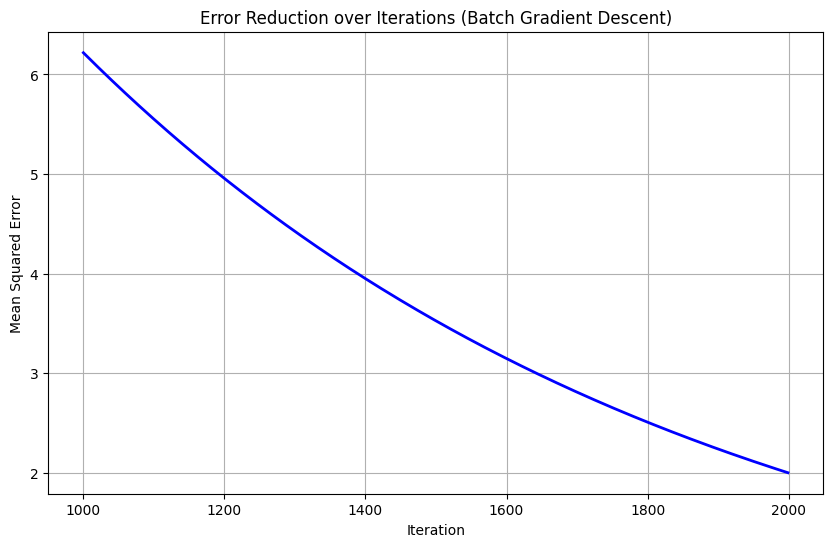

In [10]:
def plot_loss(epochs, loss_history, title):
    # Plotting the error over epochs
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, loss_history, color='blue', linewidth=2)
    plt.title(title)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error")
    plt.grid(True)
    plt.show()

plot_loss(range(1000, 2000), loss_history[1000:2000], "Error Reduction over Iterations (Batch Gradient Descent)")

<h1> # MINI Batch Gradient Descent (Mini-Batch GD) </h1>

In [11]:


#Train a Neural Network

# feed forward  and backpropagation and Training pocess untill error loss less
w1 = torch.rand(1, requires_grad=True)
w2 = torch.rand(1, requires_grad=True)
w3 = torch.rand(1, requires_grad=True)
bias = torch.rand(1, requires_grad=True)
# Lists to store the loss at each epoch
loss_history = []
epochs = 9000
learning_rate = 0.005

batch_size = 16  # Define the batch size (random)
# Number of samples
n_samples = len(performance)

for epoch in range(epochs):

          for i in range(0, n_samples, batch_size):
                    predicted_bonus = w1 * performance + w2 * years_of_experience + w3 * projects_completed + bias

                    loss = torch.mean((predicted_bonus - bonus) ** 2) ## MSE loss function

                    loss_history.append(loss.item())

                    # if loss is less than 0.001 then fine or esle tune the weigts and bias using backpropagation and gradient descent

                    # print("w1:", w1.requires_grad)
                    # print("w2:", w2.requires_grad)
                    # print("w3:", w3.requires_grad)
                    # print("bias:", bias.requires_grad)

                    # print("Prediction:", predicted_bonus.requires_grad)
                    # print("Loss:", loss.requires_grad)

                    # print("Prediction grad_fn:", predicted_bonus.grad_fn)
                    # print("Loss grad_fn:", loss.grad_fn)


                    loss.backward() ## backpropagation . without this grad won't work. and torch will track of it 

                    with torch.no_grad():  ## we don't want to track the gradients for the weights and bias while updating them. so we use torch.no_grad() context manager to update the weights and bias
                              # without tracking the gradients.
                              w1-=learning_rate * w1.grad
                              w2-=learning_rate * w2.grad
                              w3-=learning_rate * w3.grad
                              bias-=learning_rate * bias.grad

                    # zero the gradients (weigt make zero)
                    w1.grad.zero_()
                    w2.grad.zero_()
                    w3.grad.zero_()
                    bias.grad.zero_()

          # print the epoch values 

          if epoch % 100 == 0:
                    print(f"Epoch {epoch}: Loss = {loss.item():0.2f}, w1 = {w1.item():0.2f}, w2 = {w2.item():0.2f}, w3 = {w3.item():0.2f}, bias = {bias.item():0.2f}")



Epoch 0: Loss = 164.69, w1 = 10.27, w2 = 4.45, w3 = 6.76, bias = 1.64
Epoch 100: Loss = 9.13, w1 = 12.55, w2 = 4.11, w3 = 4.51, bias = 7.72
Epoch 200: Loss = 4.13, w1 = 12.37, w2 = 4.73, w3 = 3.69, bias = 11.74
Epoch 300: Loss = 1.87, w1 = 12.25, w2 = 5.15, w3 = 3.14, bias = 14.45
Epoch 400: Loss = 0.84, w1 = 12.17, w2 = 5.43, w3 = 2.76, bias = 16.27
Epoch 500: Loss = 0.38, w1 = 12.11, w2 = 5.61, w3 = 2.51, bias = 17.49
Epoch 600: Loss = 0.17, w1 = 12.08, w2 = 5.74, w3 = 2.35, bias = 18.31
Epoch 700: Loss = 0.08, w1 = 12.05, w2 = 5.83, w3 = 2.23, bias = 18.87
Epoch 800: Loss = 0.04, w1 = 12.03, w2 = 5.88, w3 = 2.16, bias = 19.24
Epoch 900: Loss = 0.02, w1 = 12.02, w2 = 5.92, w3 = 2.11, bias = 19.49
Epoch 1000: Loss = 0.01, w1 = 12.02, w2 = 5.95, w3 = 2.07, bias = 19.66
Epoch 1100: Loss = 0.00, w1 = 12.01, w2 = 5.96, w3 = 2.05, bias = 19.77
Epoch 1200: Loss = 0.00, w1 = 12.01, w2 = 5.98, w3 = 2.03, bias = 19.84
Epoch 1300: Loss = 0.00, w1 = 12.00, w2 = 5.98, w3 = 2.02, bias = 19.90
Epoc

In [13]:
len(loss_history)

63000

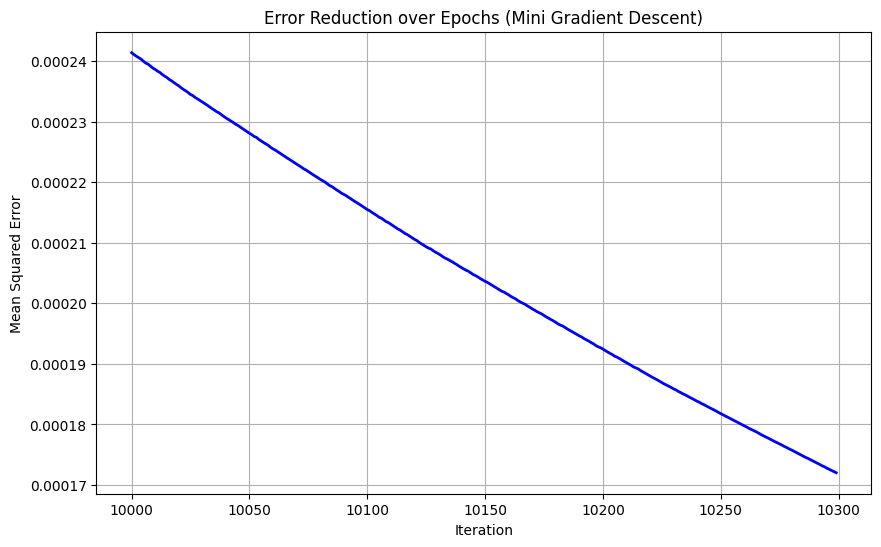

In [12]:
plot_loss(range(10000,10300), loss_history[10000:10300], "Error Reduction over Epochs (Mini Gradient Descent)")

<h1>### Stochastic Gradient Descent </h1>

In [14]:
# Initialize weights and bias randomly
w1 = torch.randn(1, requires_grad=True)
w2 = torch.randn(1, requires_grad=True)
w3 = torch.randn(1, requires_grad=True)
bias = torch.randn(1, requires_grad=True)

# Parameters for Stochastic Gradient Descent
learning_rate = 0.001
epochs = 500

# Number of samples
n_samples = len(performance)

loss_history = []

# Training loop for stochastic gradient descent
for epoch in range(epochs):
    for i in range(n_samples):
        # Select a single data point
        single_performance = performance[i]
        single_years_of_experience = years_of_experience[i]
        single_projects_completed = projects_completed[i]
        single_bonus = bonus[i]
        
        # Compute the predicted bonus using the current weights and bias
        predicted_bonus = w1 * single_performance + w2 * single_years_of_experience + w3 * single_projects_completed + bias
        
        # Compute the Mean Squared Error (MSE) loss for this data point
        loss = (predicted_bonus - single_bonus) ** 2
        
        if i%10==0:
            loss_history.append(loss.item())
        
        # Perform backpropagation to compute gradients of the loss with respect to w1, w2, w3, and bias
        loss.backward()
        
        # Update the weights and bias using the computed gradients
        with torch.no_grad():
            w1 -= learning_rate * w1.grad
            w2 -= learning_rate * w2.grad
            w3 -= learning_rate * w3.grad
            bias -= learning_rate * bias.grad

        # Zero the gradients after updating
        w1.grad.zero_()
        w2.grad.zero_()
        w3.grad.zero_()
        bias.grad.zero_()
        
    # Print the loss at regular intervals
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

# Print the learned weights and bias
print(f"Learned weights: w1 = {w1.item():.4f}, w2 = {w2.item():.4f}, w3 = {w3.item():.4f}")
print(f"Learned bias: {bias.item():.4f}")

Epoch [100/500], Loss: 0.7239
Epoch [200/500], Loss: 0.0640
Epoch [300/500], Loss: 0.0057
Epoch [400/500], Loss: 0.0005
Epoch [500/500], Loss: 0.0000
Learned weights: w1 = 12.0023, w2 = 5.9930, w3 = 2.0090
Learned bias: 19.9561


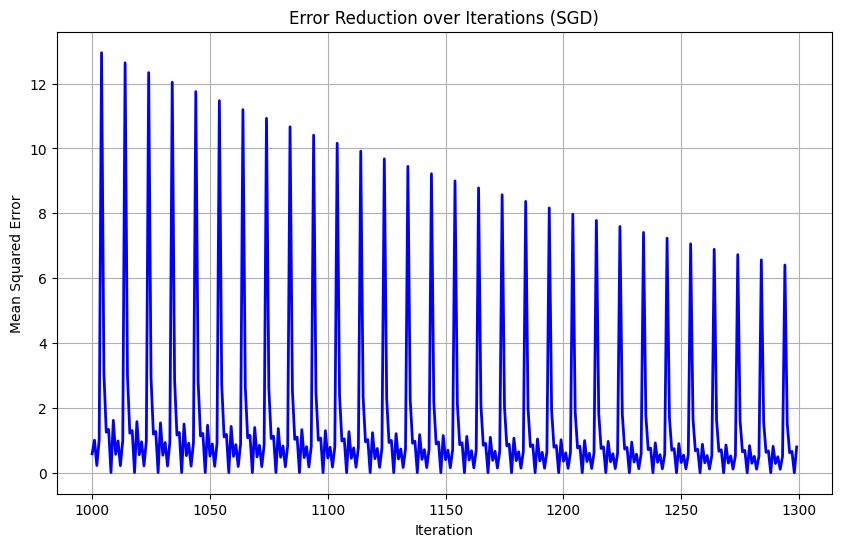

In [15]:
plot_loss(range(1000,1300), loss_history[1000:1300], "Error Reduction over Iterations (SGD)")